# Layer 3 (PFF): checking the facing direction used in RQ1

StatsBomb 360 has no body-orientation field, so Layer 1 approximates the passer's facing direction by their movement into the pass: the vector from their previous touch to the pass location (`01_layer1_visual_constraint.ipynb`, section 1). Every visible/invisible label in RQ1, RQ2 and RQ3 rests on that approximation.

PFF tracking follows every player continuously, so the passer's direction of movement just before the pass can be measured directly. `11_layer3_pff_rq3_memory.ipynb` already builds that cone for every PFF pass: the heading is the passer's movement over the last 0.5 s, sampled at 10 Hz. This notebook compares the two cones on the same World Cup passes and the same teammates.

**What this is and is not.** The PFF heading is still a movement direction, not where the passer's head or eyes point. So this is not a test against true gaze. It tests whether a direction built from two sparse event locations agrees with one measured from continuous tracking, and whether the RQ1 and RQ2 results depend on which one is used.

**Two questions.**

1. Do the two cones put the same teammates inside and outside?
2. Do the RQ1 and RQ2 headline results change when the PFF cone replaces the StatsBomb one?

**Inputs** (all saved by earlier notebooks): `pff_teammates_at_passes.pkl` (freeze-frame teammates matched to PFF players, from `09_layer3_pff_lstm_check.ipynb`), `pff_memory_mates.pkl` (the PFF cone for every teammate at every PFF pass, from `11_layer3_pff_rq3_memory.ipynb`) and `candidates_full.pkl` (values and RQ2 filters for every candidate, from `02_layer2_bias_analysis.ipynb`).

In [1]:
# shared figure settings used in every notebook:
# colours (navy, green, grey and light blue) and one folder for every saved figure
import matplotlib.pyplot as plt
from cycler import cycler
from pathlib import Path
plt.rcParams['axes.prop_cycle'] = cycler(color=['#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0'])

FIGURES = Path('../data/results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to the shared figures folder, in the same format in every notebook."""
    fig.savefig(FIGURES / name, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"saved {FIGURES / name}")



import numpy as np
import pandas as pd

RESULTS = Path('../data/results')
NAVY, GREEN, GREY, LIGHT = '#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0'

tm = pd.read_pickle(RESULTS / 'pff_teammates_at_passes.pkl')
mates = pd.read_pickle(RESULTS / 'pff_memory_mates.pkl')
cands = pd.read_pickle(RESULTS / 'candidates_full.pkl')
print(f"{len(tm)} freeze-frame teammate rows at {tm['original_event_id'].nunique()} linked World Cup passes")
print(f"{len(mates)} PFF teammate rows at {mates['possession_event_id'].nunique()} PFF passes")

365784 freeze-frame teammate rows at 35763 linked World Cup passes
684675 PFF teammate rows at 68467 PFF passes


## 1. Matching the two cones teammate by teammate

Each freeze-frame teammate already has a PFF player id where the match was clear (`09_layer3_pff_lstm_check.ipynb`, section 1). Joining on the PFF pass and that player id gives, for the same teammate at the same pass:

- `sb_cone`: inside the StatsBomb cone (the `visible` flag used in RQ1 to RQ3);
- `pff_cone`: inside the PFF cone, built from the passer's tracked movement.

A worked example: at one pass, the left centre-back (PFF id 92) is outside the StatsBomb cone. If the PFF heading puts him 140 degrees from where the passer is moving, he is outside the PFF cone too, and the two agree. If the PFF heading puts him at 40 degrees, the two disagree.

In [2]:
both = tm[tm['in_freeze_frame'] & tm['matched']].merge(
    mates[['possession_event_id', 'mate_id', 'in_cone', 'angle', 'heading_fallback']],
    left_on=['pff_possession_event_id', 'pff_player_id'],
    right_on=['possession_event_id', 'mate_id'], how='inner')
both['sb_cone'] = both['visible'].astype(bool)
both['pff_cone'] = both['in_cone'].astype(bool)
print(f"{len(both)} teammates matched in both ({len(both) / len(tm):.1%} of freeze-frame rows), "
      f"{both['original_event_id'].nunique()} passes, {both['match_id'].nunique()} matches")
print(f"inside the StatsBomb cone: {both['sb_cone'].mean():.1%}")
print(f"inside the PFF cone:       {both['pff_cone'].mean():.1%}")

225833 teammates matched in both (61.7% of freeze-frame rows), 35452 passes, 64 matches
inside the StatsBomb cone: 33.5%
inside the PFF cone:       34.9%


**What this shows**

225833 teammates have both labels: 61.7 percent of the freeze-frame teammate rows, at 35452 passes in all 64 matches. The rest had no clear PFF match. Overall the two cones are about the same size: 33.5 percent of teammates are inside the StatsBomb cone and 34.9 percent inside the PFF cone.

## 2. How often do the two cones agree?

Two measures:

- **Agreement:** the share of teammates that both cones put on the same side.
- **Cohen's kappa:** agreement corrected for the agreement expected by chance alone. With about a third of teammates inside each cone, two cones that ignored each other would still agree on about 55 percent of teammates (two thirds of the time both say "outside"). Kappa is 0 for chance-level agreement and 1 for perfect agreement; 0.4 to 0.6 is usually called moderate.

The 95 percent intervals resample whole matches.

In [3]:
def agreement(d):
    a, b = d['sb_cone'].to_numpy(), d['pff_cone'].to_numpy()
    po = (a == b).mean()
    pe = a.mean() * b.mean() + (1 - a.mean()) * (1 - b.mean())
    return po, (po - pe) / (1 - pe)

print(pd.crosstab(both['sb_cone'].rename('StatsBomb cone'), both['pff_cone'].rename('PFF cone'), margins=True))
po, kappa = agreement(both)

rng = np.random.default_rng(0)
groups = {m: d for m, d in both.groupby('match_id')}
keys = list(groups)
boot = []
for _ in range(1000):
    sample = pd.concat([groups[k] for k in rng.choice(keys, len(keys))])
    boot.append(agreement(sample))
boot = np.array(boot)
print(f"\nagreement {po:.1%} (95% CI {np.percentile(boot[:, 0], 2.5):.1%} to {np.percentile(boot[:, 0], 97.5):.1%})")
print(f"kappa     {kappa:.3f} (95% CI {np.percentile(boot[:, 1], 2.5):.3f} to {np.percentile(boot[:, 1], 97.5):.3f})")

print('\nby whether the PFF heading had to fall back to facing the opponent goal:')
for fb, d in both.groupby('heading_fallback'):
    p, k = agreement(d)
    print(f"  fallback={fb}: {len(d)} teammates, agreement {p:.1%}, kappa {k:.3f}")

PFF cone         False   True     All
StatsBomb cone                       
False           118240  31927  150167
True             28666  47000   75666
All             146906  78927  225833

agreement 73.2% (95% CI 72.3% to 74.0%)
kappa     0.404 (95% CI 0.384 to 0.425)

by whether the PFF heading had to fall back to facing the opponent goal:
  fallback=False: 223318 teammates, agreement 73.4%, kappa 0.408
  fallback=True: 2515 teammates, agreement 55.4%, kappa 0.061


**What this shows**

**The two cones agree on about three teammates in four.** Agreement is 73.2 percent (95 percent CI 72.3 to 74.0) and kappa is 0.40 (0.38 to 0.43), which is moderate.

A worked example of kappa: with 33.5 and 34.9 percent inside, two unrelated cones would agree by chance on 0.335 × 0.349 + 0.665 × 0.651 = 55.0 percent of teammates. The cones actually agree on 73.2 percent, which is 18.2 of the 45.0 points possible above chance: 18.2 / 45.0 = 0.40.

**The disagreements are balanced.** 28666 teammates are inside the StatsBomb cone only and 31927 inside the PFF cone only. So the StatsBomb direction is not pointing systematically wrong or making the cone too wide; it is noisy.

When the PFF heading had to fall back to facing the opponent goal (the passer barely moving), agreement drops to chance (kappa 0.06). This affects only 2515 teammates, 1.1 percent.

## 3. Where do they disagree?

If the StatsBomb direction is a noisier version of the tracked one, the disagreements should sit near the edge of the cone, where a small change in direction moves a teammate from one side to the other. The table and figure show, for teammates grouped by their angle from the PFF heading, how often the StatsBomb cone counts them as inside.

                teammates  inside_sb_cone
angle_band                               
(-0.001, 30.0]      40003           0.671
(30.0, 50.0]        25959           0.555
(50.0, 60.0]        12965           0.443
(60.0, 70.0]        13018           0.355
(70.0, 90.0]        26673           0.261
(90.0, 135.0]       58273           0.170
(135.0, 180.0]      48942           0.147
saved ..\data\results\figures\rq1_pff_facing_by_angle.png


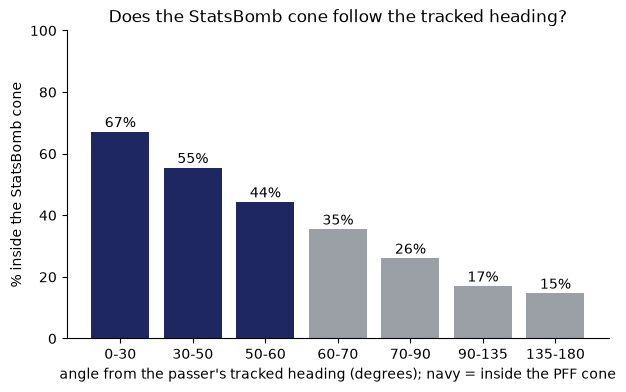

In [4]:
bands = [0, 30, 50, 60, 70, 90, 135, 180]
both['angle_band'] = pd.cut(both['angle'], bands, include_lowest=True)
by_angle = both.groupby('angle_band', observed=True).agg(teammates=('sb_cone', 'size'),
                                                          inside_sb_cone=('sb_cone', 'mean'))
print(by_angle.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
labels = [f"{int(b.left)}-{int(b.right)}" for b in by_angle.index]
colours = [NAVY if b.right <= 60 else GREY for b in by_angle.index]
ax.bar(labels, 100 * by_angle['inside_sb_cone'], color=colours)
for i, v in enumerate(100 * by_angle['inside_sb_cone']):
    ax.text(i, v + 1.5, f"{v:.0f}%", ha='center', fontsize=10)
ax.set_xlabel('angle from the passer\'s tracked heading (degrees); navy = inside the PFF cone')
ax.set_ylabel('% inside the StatsBomb cone')
ax.set_ylim(0, 100)
ax.set_title('Does the StatsBomb cone follow the tracked heading?')
ax.spines[['top', 'right']].set_visible(False)
save_fig(fig, 'rq1_pff_facing_by_angle.png')
plt.show()

**What this shows**

**The StatsBomb cone follows the tracked heading, with a lot of noise.** The share of teammates inside the StatsBomb cone falls steadily with the angle from the tracked heading, from 67 percent straight ahead to 15 percent behind the passer. The noise is not only at the edge of the cone: even teammates within 30 degrees of the tracked heading are outside the StatsBomb cone a third of the time.

This is what the proxy predicts. The StatsBomb direction joins the previous touch to the pass location, and the previous touch can be several seconds earlier, so a passer who has since turned is given an out-of-date direction. The PFF direction is the movement over the last 0.5 s.

## 4. Do RQ1 and RQ2 change with the PFF cone?

The test that matters for the thesis: recompute the two headline results on the same passes, once with each cone, with everything else unchanged.

- **RQ1:** among passes with at least one teammate inside the cone, the share where the best option inside the cone differs from the best option among all teammates (the definition in `01_layer1_visual_constraint.ipynb`).
- **RQ2:** the share of passes with at least one legitimate maximal-VAEP option: inside the cone, onside, xP at least 0.05, and a higher VAEP value than the pass that was played (the definition in `02_layer2_bias_analysis.ipynb`).

Only passes where every freeze-frame teammate has a PFF match are used, so both versions see exactly the same teammates. The interval for the difference resamples whole matches.

In [5]:
cone_pff = both.set_index('cand_index')['pff_cone']
cw = cands[cands['original_event_id'].isin(both['original_event_id'].unique())].join(cone_pff, how='left')
complete = cw.groupby('original_event_id')['pff_cone'].apply(lambda s: s.notna().all())
cw = cw[cw['original_event_id'].isin(complete[complete].index)].copy()
cw['sb_cone'] = cw['visible'].astype(bool)
cw['pff_cone'] = cw['pff_cone'].astype(bool)
usable = (cw['offside'].fillna(True).astype(bool) == False) & (cw['xp_value'] >= 0.05) & cw['forward_progressive'].astype(bool)

# sanity check: the StatsBomb version must reproduce the stored RQ2 flag exactly
stored = cw['legitimate_forward_progressive'].fillna(False).astype(bool).groupby(cw['original_event_id']).any()
assert ((usable & cw['sb_cone']).groupby(cw['original_event_id']).any() == stored).all()


def pass_flags(df, cone):
    best_all = df.groupby('original_event_id')['candidate_value'].idxmax()
    best_in = df[df[cone]].groupby('original_event_id')['candidate_value'].idxmax()
    rq1 = pd.Series(best_all.loc[best_in.index].to_numpy() != best_in.to_numpy(), index=best_in.index)
    rq2 = (usable.loc[df.index] & df[cone]).groupby(df['original_event_id']).any()
    return rq1, rq2


flags = {cone: pass_flags(cw, cone) for cone in ['sb_cone', 'pff_cone']}
match_of = cw.groupby('original_event_id')['match_id'].first()
print(f"{cw['original_event_id'].nunique()} passes in {cw['match_id'].nunique()} matches with every teammate matched\n")

summary = {}
for k, name in enumerate(['RQ1 best option changes', 'RQ2 forward-bias rate']):
    sb, pf = flags['sb_cone'][k], flags['pff_cone'][k]
    per = pd.DataFrame({'sb_k': sb.groupby(match_of.loc[sb.index]).sum(), 'sb_n': sb.groupby(match_of.loc[sb.index]).size(),
                        'pf_k': pf.groupby(match_of.loc[pf.index]).sum(), 'pf_n': pf.groupby(match_of.loc[pf.index]).size()})
    idx = rng.integers(0, len(per), size=(5000, len(per)))
    s = per.to_numpy()[idx].sum(axis=1)
    diff = s[:, 2] / s[:, 3] - s[:, 0] / s[:, 1]
    summary[name] = {'sb': sb.mean(), 'sb_n': len(sb), 'pff': pf.mean(), 'pff_n': len(pf),
                     'diff': pf.mean() - sb.mean(), 'lo': np.percentile(diff, 2.5), 'hi': np.percentile(diff, 97.5)}
    print(f"{name}: StatsBomb cone {sb.mean():.1%} (n={len(sb)}), PFF cone {pf.mean():.1%} (n={len(pf)}), "
          f"difference {100 * (pf.mean() - sb.mean()):+.1f} points (95% CI {100 * np.percentile(diff, 2.5):+.1f} to {100 * np.percentile(diff, 97.5):+.1f})")

both_rq2 = pd.concat([flags['sb_cone'][1].rename('sb'), flags['pff_cone'][1].rename('pff')], axis=1)
print(f"\nRQ2 flag is the same under both cones for {(both_rq2['sb'] == both_rq2['pff']).mean():.1%} of passes")

C:\Users\raees\AppData\Local\Temp\ipykernel_8456\3267920754.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  usable = (cw['offside'].fillna(True).astype(bool) == False) & (cw['xp_value'] >= 0.05) & cw['forward_progressive'].astype(bool)


30634 passes in 64 matches with every teammate matched

RQ1 best option changes: StatsBomb cone 58.7% (n=25432), PFF cone 58.2% (n=25992), difference -0.4 points (95% CI -1.2 to +0.3)
RQ2 forward-bias rate: StatsBomb cone 36.9% (n=30634), PFF cone 38.6% (n=30634), difference +1.7 points (95% CI +1.1 to +2.3)

RQ2 flag is the same under both cones for 79.6% of passes


saved ..\data\results\figures\rq1_pff_facing_check.png


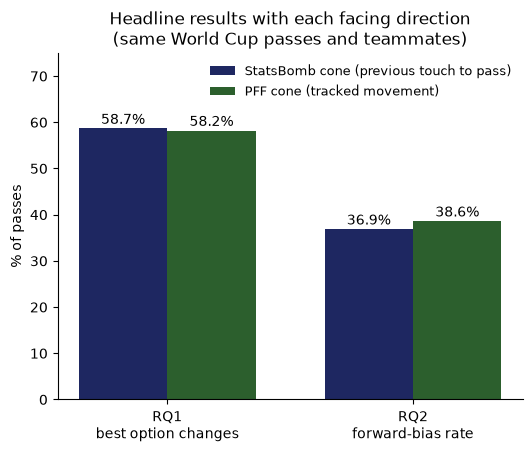

In [6]:
fig, ax = plt.subplots(figsize=(6, 4.5))
names = list(summary)
x = np.arange(len(names))
w = 0.36
for j, (key, label, colour) in enumerate([('sb', 'StatsBomb cone (previous touch to pass)', NAVY),
                                          ('pff', 'PFF cone (tracked movement)', GREEN)]):
    vals = [100 * summary[n][key] for n in names]
    ax.bar(x + (j - 0.5) * w, vals, w, color=colour, label=label)
    for xi, v in zip(x + (j - 0.5) * w, vals):
        ax.text(xi, v + 1, f"{v:.1f}%", ha='center', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(['RQ1\nbest option changes', 'RQ2\nforward-bias rate'])
ax.set_ylabel('% of passes')
ax.set_ylim(0, 75)
ax.set_title('Headline results with each facing direction\n(same World Cup passes and teammates)')
ax.legend(loc='upper right', fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
save_fig(fig, 'rq1_pff_facing_check.png')
plt.show()

**What this shows**

**RQ1 does not change.** With the PFF cone, the best option changes on 58.2 percent of passes, against 58.7 percent with the StatsBomb cone (difference -0.4 points, 95 percent CI -1.2 to +0.3).

**RQ2 changes very little, and in the direction that strengthens it.** The forward-bias rate is 38.6 percent with the PFF cone and 36.9 percent with the StatsBomb cone (+1.7 points, CI +1.1 to +2.3). So the StatsBomb proxy, if anything, slightly understates the bias.

**Individual passes do change.** The RQ2 flag is the same under both cones for 79.6 percent of passes. The proxy moves individual teammates in and out of the cone, but these changes cancel out in the rates.

(The rates here are on the 30634 World Cup passes where every teammate has a PFF match, so they differ slightly from the 166-match headlines.)

## 5. Save

In [7]:
out = {'teammates': len(both), 'agreement': po, 'kappa': kappa,
       'agreement_ci': (np.percentile(boot[:, 0], 2.5), np.percentile(boot[:, 0], 97.5)),
       'kappa_ci': (np.percentile(boot[:, 1], 2.5), np.percentile(boot[:, 1], 97.5)),
       'by_angle': by_angle, 'headline': summary}
pd.to_pickle(out, RESULTS / 'pff_facing_check.pkl')
print('saved pff_facing_check.pkl')

saved pff_facing_check.pkl


## Summary

**The facing direction used in RQ1 to RQ3 is noisy but unbiased, and the headline results do not depend on it.**

- On 225833 teammates at 35452 World Cup passes, the StatsBomb cone (previous touch to pass) and the PFF cone (tracked movement over the last 0.5 s) agree on 73.2 percent of teammates, kappa 0.40. The disagreements are balanced in both directions.
- The StatsBomb cone follows the tracked heading: teammates straight ahead are inside it 67 percent of the time, teammates behind the passer 15 percent.
- On the same passes, RQ1 is unchanged (58.7 percent with the StatsBomb cone, 58.2 percent with the PFF cone) and the RQ2 forward-bias rate moves from 36.9 to 38.6 percent.

**For the write-up.** The proxy is a documented adaptation (StatsBomb has no orientation field). This check shows it adds noise for individual teammates but does not drive the RQ1 or RQ2 conclusions. Both cones are built from movement direction, not head or eye direction, so neither captures quick glances over the shoulder. That limit applies to the whole framework and is discussed with RQ3.

Saved: `pff_facing_check.pkl`, `figures/rq1_pff_facing_by_angle.png`, `figures/rq1_pff_facing_check.png`.